# Data Loading and Sparsity
Load the user-item interaction data from the local directory, drop unnecessary columns, and calculate the overall matrix sparsity to understand data density.

In [6]:
import pandas as pd

df = pd.read_csv('data/ratings.csv')
df = df.drop(columns=['timestamp'])

total_interactions = len(df)
total_users = df['userId'].nunique()
total_items = df['movieId'].nunique()
sparsity = 1 - (total_interactions / (total_users * total_items))

print(f"Matrix Sparsity: {sparsity:.4%}")
df.head()

Matrix Sparsity: 98.3000%


,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


# Exploratory Data Analysis
Analyze the distribution of ratings, active users, the long-tail effect of popular items, and visualize user-item interaction patterns using a sparse matrix heatmap.

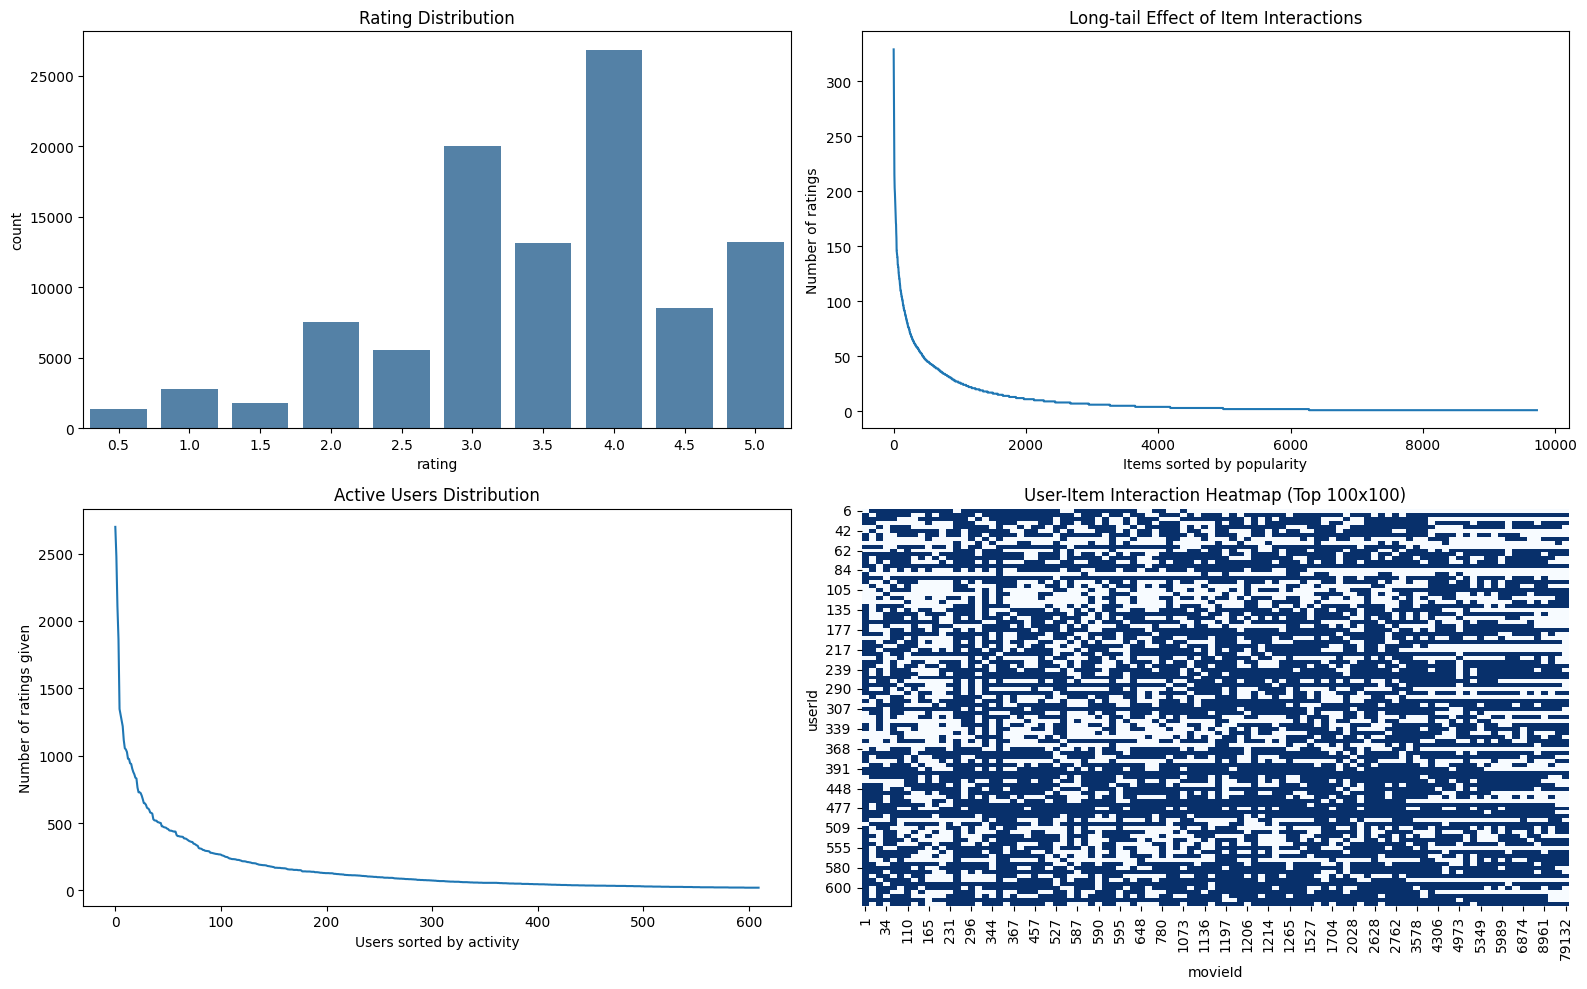

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=df, x='rating', color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Rating Distribution')

item_counts = df['movieId'].value_counts().values
axes[0, 1].plot(item_counts)
axes[0, 1].set_title('Long-tail Effect of Item Interactions')
axes[0, 1].set_xlabel('Items sorted by popularity')
axes[0, 1].set_ylabel('Number of ratings')

user_counts = df['userId'].value_counts().values
axes[1, 0].plot(user_counts)
axes[1, 0].set_title('Active Users Distribution')
axes[1, 0].set_xlabel('Users sorted by activity')
axes[1, 0].set_ylabel('Number of ratings given')

top_users = df['userId'].value_counts().head(100).index
top_items = df['movieId'].value_counts().head(100).index
sample_df = df[df['userId'].isin(top_users) & df['movieId'].isin(top_items)]
interaction_matrix = sample_df.pivot(index='userId', columns='movieId', values='rating')
sns.heatmap(interaction_matrix.notnull(), cbar=False, cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('User-Item Interaction Heatmap (Top 100x100)')

plt.tight_layout()
plt.show()

# Dataset Preparation
Format the dataframe for the Surprise library by defining the reader rating scale.

In [8]:
from surprise import Reader, Dataset

reader = Reader(rating_scale=(df['rating'].min(), df['rating'].max()))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

# Model Training and Basic Evaluation
Split the data into training and testing sets, apply Matrix Factorization using Singular Value Decomposition, and calculate fundamental error metrics.

In [9]:
from surprise import SVD, accuracy
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

model = SVD(random_state=42)
model.fit(trainset)

predictions = model.test(testset)
print("RMSE and MAE evaluation:")
accuracy.rmse(predictions)
accuracy.mae(predictions)

RMSE and MAE evaluation:
RMSE: 0.8807
MAE:  0.6766


0.6765729095860605

# Advanced Evaluation Metrics
Calculate Precision@K and Recall@K to evaluate the top-K recommendation quality across all users in the test set.

In [10]:
from collections import defaultdict

def precision_recall_at_k(predictions, k=5, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in user_ratings[:k])

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 1
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 1

    mean_precision = sum(precisions.values()) / len(precisions)
    mean_recall = sum(recalls.values()) / len(recalls)
    return mean_precision, mean_recall

precision, recall = precision_recall_at_k(predictions, k=5, threshold=3.5)
print(f"Precision@5: {precision:.4f}")
print(f"Recall@5: {recall:.4f}")

Precision@5: 0.8222
Recall@5: 0.3992


# Generating Recommendations and Personalization Analysis
Generate top N recommendations for a specific user and compare their global popularity to ensure the model provides diverse and personalized content, rather than just suggesting global blockbusters.

In [11]:
def get_top_n_recommendations(user_id, n=5):
    all_movie_ids = df['movieId'].unique()
    user_interacted_movies = set(df[df['userId'] == user_id]['movieId'])
    movies_to_predict = [m for m in all_movie_ids if m not in user_interacted_movies]

    user_predictions = [model.predict(user_id, movie_id) for movie_id in movies_to_predict]
    user_predictions.sort(key=lambda x: x.est, reverse=True)

    return [pred.iid for pred in user_predictions[:n]]

target_user = 1
top_recommended_movies = get_top_n_recommendations(user_id=target_user, n=5)
print(f"Top 5 recommendations for User {target_user}: {top_recommended_movies}\n")

item_popularity = df['movieId'].value_counts()
global_top_5 = item_popularity.head(5).index.tolist()
print(f"Global Top 5 most popular movies: {global_top_5}\n")

print("Popularity of recommended movies (Number of ratings globally):")
for movie in top_recommended_movies:
    pop_count = item_popularity.get(movie, 0)
    print(f"Movie {movie}: {pop_count} ratings")

Top 5 recommendations for User 1: [48516, 908, 912, 2019, 750]

Global Top 5 most popular movies: [356, 318, 296, 593, 2571]

Popularity of recommended movies (Number of ratings globally):
Movie 48516: 107 ratings
Movie 908: 57 ratings
Movie 912: 100 ratings
Movie 2019: 48 ratings
Movie 750: 97 ratings
